# Building Structural Causal Models: An End-to-End Workflow with DoWhy, EconML, and Refutation Tests

## From Assumptions to Counterfactuals: A Practical Causal Modeling Workflow

### Abstract

This post presents an end-to-end workflow for building and validating causal models using DoWhy, EconML, and structural causal modeling concepts. The focus is not just on estimating treatment effects, but on making assumptions explicit, validating identification, and stress-testing conclusions through refutation and counterfactual analysis.

---

This analysis demonstrates how to move from a causal question to a fully specified and validated causal model.

Rather than treating causal estimation as a single modeling step, the workflow emphasizes:

- explicitly encoding assumptions through a causal graph  
- identifying the estimand before estimation  
- using flexible models (e.g., Double Machine Learning) for effect estimation  
- validating results through refutation and robustness checks  
- generating counterfactual insights using structural models  

---

## Data and setup

To keep the workflow self-contained and reproducible, we use a public dataset (`sklearn.datasets.load_diabetes`) and simulate treatment and outcome variables. This allows us to work in a setting where the causal structure is known, making it easier to validate each step of the pipeline.

---

## Framing

The goal is not just to estimate a treatment effect, but to demonstrate how causal reasoning, modeling, and validation fit together into a coherent workflow.

In particular:

- how assumptions influence what can be estimated  
- how identification differs from estimation  
- why refutation tests are critical before trusting results  
- how structural models enable counterfactual reasoning  

---

## Core question

> How do we move from a causal question to a validated model that supports reliable counterfactual reasoning?

## Background and references

This workflow is informed by standard causal inference frameworks and tooling, including approaches implemented in DoWhy and EconML.

- Molak, A. *Causal Inference and Discovery in Python*

The focus here is on applying these ideas in an end-to-end workflow and examining their practical implications.

## 0) Setup
We try to import `dowhy` and `econml`. If they are missing, install them.

If you are in a restricted environment without pip access, run this notebook where you can `pip install`.

In [1]:
import sys
import subprocess

def pip_install(pkg):
    print(f"Installing: {pkg}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Core deps
for pkg in ["dowhy", "econml", "scikit-learn", "pandas", "numpy", "matplotlib", "networkx"]:
    try:
        __import__(pkg.split("==")[0])
    except Exception:
        pip_install(pkg)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Installing: scikit-learn


In [2]:
import warnings
from sklearn.exceptions import DataConversionWarning

warnings.simplefilter("ignore", DataConversionWarning)

## 1) Create a public dataset + simulate a causal story

We start with the Diabetes dataset covariates `W`.
Then we create:
- **Treatment `X`**: depends on some covariates (confounding)
- **Outcome `Y`**: depends on `X` + covariates

We choose a **true causal effect** of `X → Y` to be **about 0.7**.

In [3]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)

data = load_diabetes(as_frame=True)
W = data.frame.copy()

# Standardize covariates so our simulation coefficients are stable
scaler = StandardScaler()
W_scaled = pd.DataFrame(scaler.fit_transform(W), columns=W.columns)

n = len(W_scaled)

# Simulate a confounder-like latent signal using observed covariates
u = rng.normal(0, 1, size=n)

# Treatment X depends on covariates (confounding)
# (Continuous treatment to match the chapter’s DML regression example)
X = (
    0.6 * W_scaled["bmi"].to_numpy() +
    0.3 * W_scaled["bp"].to_numpy() +
    0.2 * W_scaled["s5"].to_numpy() +
    0.3 * u +
    rng.normal(0, 0.5, size=n)
)

TRUE_ATE = 0.7

# Outcome Y depends on X and covariates
Y = (
    TRUE_ATE * X +
    0.4 * W_scaled["bmi"].to_numpy() +
    0.2 * W_scaled["age"].to_numpy() -
    0.3 * W_scaled["s1"].to_numpy() +
    0.2 * u +
    rng.normal(0, 1.0, size=n)
)

df = W_scaled.copy()
df["X"] = X
df["Y"] = Y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,X,Y
0,0.800500,1.065488,1.297088,0.459841,-0.929746,-0.732065,-0.912451,-0.054499,0.418531,-0.370989,-0.014719,1.272287,0.816080
1,-0.039567,-0.938537,-1.082180,-0.553505,-0.177624,-0.402886,1.564414,-0.830301,-1.436589,-1.938479,-1.001659,-0.754342,-0.834617
2,1.793307,1.065488,0.934533,-0.119214,-0.958674,-0.718897,-0.680245,-0.054499,0.060156,-0.545154,-0.144580,0.590729,2.828625
3,-1.872441,-0.938537,-0.243771,-0.770650,0.256292,0.525397,-0.757647,0.721302,0.476983,-0.196823,0.699513,-0.738321,-1.308935
4,0.113172,-0.938537,-0.764944,0.459841,0.082726,0.327890,0.171178,-0.054499,-0.672502,-0.980568,-0.222496,-0.507214,-3.555118


### Quick sanity check
- If we run a **naive regression** of Y on X *without controlling for confounders*, it can be biased.
- If we control for the right covariates, we should recover something close to the true effect (~0.7).

In [4]:
import statsmodels.api as sm

# Naive
X_naive = sm.add_constant(df[["X"]])
naive = sm.OLS(df["Y"], X_naive).fit()
print("Naive OLS coef on X:", naive.params["X"])

# Adjusted (include a bunch of covariates)
controls = [c for c in df.columns if c not in ["X", "Y"]]
X_adj = sm.add_constant(df[["X"] + controls])
adj = sm.OLS(df["Y"], X_adj).fit()
print("Adjusted OLS coef on X:", adj.params["X"])
print("True effect:", TRUE_ATE)

Naive OLS coef on X: 1.027198098583941
Adjusted OLS coef on X: 0.9013676299101012
True effect: 0.7


## 2) DoWhy Step 1 — Encode assumptions (DAG)

We now write a causal graph.

We’ll use a simple and realistic assumption:
- Several covariates **W** affect both **X** and **Y** (confounders)
- **X** affects **Y**

In DoWhy, you provide the graph as a string.

digraph {
bmi -> X;
bmi -> Y;
bp -> X;
bp -> Y;
s5 -> X;
s5 -> Y;
age -> X;
age -> Y;
s1 -> X;
s1 -> Y;
X -> Y;
}


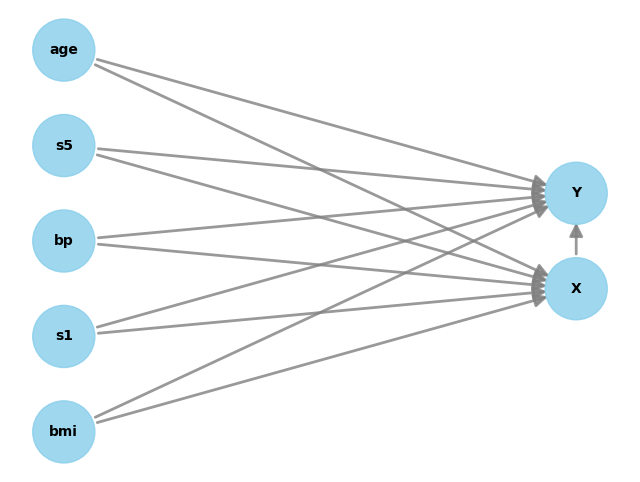

In [5]:
from dowhy import CausalModel

# We'll include a small subset of covariates to keep the graph readable.
confounders = ["bmi", "bp", "s5", "age", "s1"]

# Build a graph string (DOT format for DoWhy)
# Edges: confounders -> X and confounders -> Y, plus X -> Y

edges = []
for w in confounders:
    edges.append(f"{w} -> X")
    edges.append(f"{w} -> Y")
edges.append("X -> Y")

graph = "digraph {\n" + ";\n".join(edges) + ";\n}"

print(graph)

from dowhy import CausalModel



model = CausalModel(
    data=df[["Y", "X"] + confounders],
    treatment="X",
    outcome="Y",
    graph=graph
)

model.view_model()

## 3) DoWhy Step 2 — Identify the estimand

Now DoWhy uses the graph to answer:

> “What expression can I compute from data to get the causal effect of X on Y?”

Usually, you’ll see it choose a **backdoor adjustment set** (control variables).

In [6]:
estimand = model.identify_effect()
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d                         
────(E[Y|bmi,s1,bp,s5,age])
d[X]                       
Estimand assumption 1, Unconfoundedness: If U→{X} and U→Y then P(Y|X,bmi,s1,bp,s5,age,U) = P(Y|X,bmi,s1,bp,s5,age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
 d                         
────(E[Y|bmi,s1,bp,s5,age])
d[X]                       
Estimand assumption 1, Unconfoundedness: If U→{X} and U→Y then P(Y|X,bmi,s1,bp,s5,age,U) = P(Y|X,bmi,s1,bp,s5,age)



## 4) DoWhy Step 3 — Estimate the effect

We estimate the causal effect using two estimators:

1. **Linear regression** (simple baseline)
2. **Double ML (DML)** via **EconML** (more flexible, ML-based)

We then compare results to the **known true effect** (~0.7).

In [7]:
# 4.1 Linear regression estimator inside DoWhy
estimate_lr = model.estimate_effect(
    identified_estimand=estimand,
    method_name="backdoor.linear_regression"
)
print("DoWhy Linear Regression ATE:", estimate_lr.value)
print("True effect:", TRUE_ATE)

DoWhy Linear Regression ATE: 0.8933354974909338
True effect: 0.7


In [8]:
# 4.2 Double ML estimator via EconML
# We'll use gradient boosting to model the nuisance functions
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LassoCV

estimate_dml = model.estimate_effect(
    identified_estimand=estimand,
    method_name="backdoor.econml.dml.DML",
    method_params={
        "init_params": {
        "model_y": GradientBoostingRegressor(random_state=42),
        "model_t": GradientBoostingRegressor(random_state=42),
        "model_final": LassoCV(fit_intercept=False, random_state=42),
        },
        "fit_params": {}
    }
)
print("DoWhy + EconML DML ATE:", estimate_dml.value)
print("True effect:", TRUE_ATE)

DoWhy + EconML DML ATE: 0.8414075808313225
True effect: 0.7


### Interpretation
- If both estimates are close to ~0.7, our identification + estimation is behaving properly.
- In real projects, you **don’t know** the true effect — so you rely more on:
  - refutation tests
  - sensitivity checks
  - domain validation

## 5) DoWhy Step 4 — Refute the estimate (robustness tests)

Refutation tests try to **break** your causal result.

We’ll run a standard set of robustness tests to stress-test the causal estimate:

1. **Data subset refuter** (invariant transformation)
2. **Random common cause** (invariant transformation)
3. **Placebo treatment refuter** (nullifying transformation)

Key idea:
- Invariant transformations should **not** change the estimate much.
- Nullifying transformations should make the effect go to **~0**.

In [9]:
# We'll refute the DML estimate (you can also refute the linear one)

print("Original DML estimate:", estimate_dml.value)

Original DML estimate: 0.8414075808313225


In [10]:
# 5.1 Data subset refuter
refute_subset = model.refute_estimate(
    estimand=estimand,
    estimate=estimate_dml,
    method_name="data_subset_refuter",
    subset_fraction=0.4,
    random_seed=42
)
print(refute_subset)

Refute: Use a subset of data
Estimated effect:0.8414075808313225
New effect:0.8394171759658877
p value:0.98



In [11]:
# 5.2 Random common cause
refute_random_cc = model.refute_estimate(
    estimand=estimand,
    estimate=estimate_dml,
    method_name="random_common_cause",
    random_seed=42
)
print(refute_random_cc)

Refute: Add a random common cause
Estimated effect:0.8414075808313225
New effect:0.8432973506633976
p value:0.94



In [12]:
# 5.3 Placebo treatment refuter
refute_placebo = model.refute_estimate(
    estimand=estimand,
    estimate=estimate_dml,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    random_seed=42
)
print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:0.8414075808313225
New effect:0.0016584462823585782
p value:0.98



### How to read refutation outputs
Typically you see:
- **Estimated effect** (original)
- **New effect** (after refutation)
- **p-value** for the difference

What you want:
- subset/common-cause: new effect ≈ old effect (difference not significant)
- placebo: new effect ≈ 0

## 6) GCM API (extra) — structural causal modeling + counterfactuals

DoWhy’s **GCM** API lets you go beyond ATE and ask:

- “How strong are the incoming causal arrows into Y?”
- “What would Y have been if we set X to another value (counterfactual)?”

This requires specifying a **causal mechanism** for each node.

We’ll build a small graph with the same variables used above.

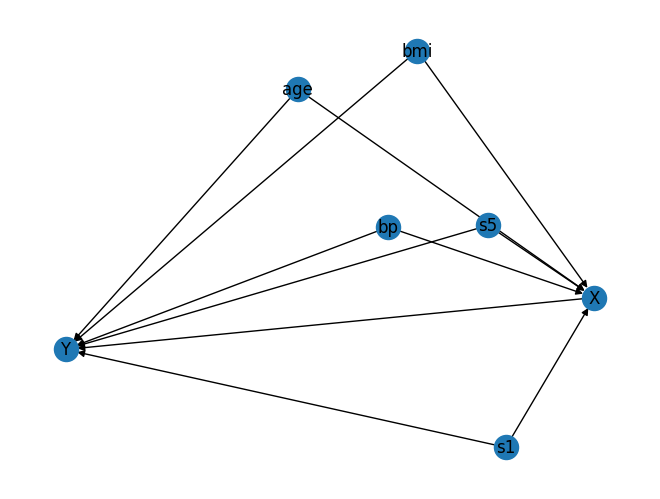

In [13]:
import networkx as nx
from dowhy import gcm
from sklearn.linear_model import LinearRegression

# Build the same causal structure using NetworkX
G = nx.DiGraph()

for w in confounders:
    G.add_edge(w, "X")
    G.add_edge(w, "Y")
G.add_edge("X", "Y")

# Plot (optional)
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True)
plt.show()

In [14]:
from dowhy import gcm
from sklearn.linear_model import LinearRegression
from dowhy.gcm.ml import SklearnRegressionModel

# Create an invertible SCM (good for counterfactuals)
causal_model = gcm.InvertibleStructuralCausalModel(G)

# Root nodes as empirical distributions
for w in confounders:
    causal_model.set_causal_mechanism(w, gcm.EmpiricalDistribution())

# X and Y as additive noise models with wrapped sklearn regressors
causal_model.set_causal_mechanism("X", gcm.AdditiveNoiseModel(SklearnRegressionModel(LinearRegression())))
causal_model.set_causal_mechanism("Y", gcm.AdditiveNoiseModel(SklearnRegressionModel(LinearRegression())))

# Fit mechanisms to data
gcm.fit(causal_model, df[["X", "Y"] + confounders])
print("GCM fitted.")


Fitting causal mechanism of node s1: 100%|██████████████████████████████████████████████| 7/7 [00:00<00:00, 246.91it/s]

GCM fitted.


### 6.1 Arrow strength into Y
This gives a measure of how much each parent contributes to explaining Y.
This is **not exactly the same as ATE**.
It’s more like: “How important is this causal parent in the model for Y?”

In [15]:
strengths = gcm.arrow_strength(causal_model, "Y")
strengths

{('X', 'Y'): np.float64(0.7045566616574985),
 ('age', 'Y'): np.float64(0.04788431176770035),
 ('bmi', 'Y'): np.float64(0.15649327627968032),
 ('bp', 'Y'): np.float64(0.01957459130750313),
 ('s1', 'Y'): np.float64(0.08355406661605072),
 ('s5', 'Y'): np.float64(0.009460206774970321)}

### 6.2 Counterfactual example
Counterfactual question:

> For a specific observation, what would Y be if we forced X to some value?

We pick one row and set `X` to a new value.

In [16]:
row = df[["X", "Y"] + confounders].iloc[[0]].copy()
row

,X,Y,bmi,bp,s5,age,s1
0,1.272287,0.81608,1.297088,0.459841,0.418531,0.8005,-0.929746


In [17]:
# Force X to a new value (intervention)
new_x = float(row["X"].iloc[0] - 1.0)  # just as an example

cf = gcm.counterfactual_samples(
    causal_model,
    interventions={"X": lambda _: new_x},
    observed_data=row
)

print("Observed:")
print(row[["X", "Y"] + confounders])
print("Counterfactual (X forced to new value):")
print(cf[["X", "Y"] + confounders])

Observed:
          X        Y       bmi        bp        s5     age        s1
0  1.272287  0.81608  1.297088  0.459841  0.418531  0.8005 -0.929746
Counterfactual (X forced to new value):
          X         Y       bmi        bp        s5     age        s1
0  0.272287 -0.077256  1.297088  0.459841  0.418531  0.8005 -0.929746


## 7) Key takeaways

- **DoWhy** provides a structured causal workflow: define assumptions (graph) → identify the estimand → estimate the effect → refute the result.  
- **EconML** enables flexible estimation using modern methods (e.g., DML) when linear models are insufficient.  
- **Refutation tests** act as validation checks by stress-testing the estimated effect (e.g., placebo treatment, random common cause).  
- **Structural causal models (GCM)** extend the analysis beyond estimation to counterfactual reasoning under interventions.

---

## Practical guidance

In real-world settings (e.g., marketing, personalization), a robust minimum causal workflow should include:

- A clearly defined **causal graph (DAG)** with explicit assumptions  
- At least one **identified estimand** (e.g., backdoor adjustment using regression or DML)  
- A **refutation suite**:
  - placebo treatment  
  - random common cause  
  - subset validation (when feasible)  
- Basic **sensitivity checks** to understand how conclusions change under perturbations  

Crucially, estimation alone is not sufficient.  
If a result does not hold under simple refutations, it should not be trusted—regardless of model complexity.

---

## Final takeaway

Causal modeling is not just about estimating effects—it is about making assumptions explicit, validating them rigorously, and understanding how conclusions change under stress.

In practice, tools like DoWhy and EconML provide a structured framework, but their outputs are only as reliable as the assumptions behind them. Refutation tests and sensitivity checks are essential for distinguishing real causal signal from modeling artifacts.

More importantly, the goal is not just to estimate an average effect, but to support **decision-making under intervention**. Whether through policy changes, targeting strategies, or counterfactual analysis, the value of causal models lies in how they inform actions—not just how well they fit data.

Without this discipline, even sophisticated models can produce confident but misleading conclusions.

Ultimately, better causal models don’t just answer questions—they change decisions.